In [1]:
library(tidyterra)
library(terra)
library(geodata)
library(rnaturalearth)
library(ggplot2)
library(dplyr)
library(sf)
library(rlang)
library(knitr)
library(patchwork)
library(leaflet)
library(htmlwidgets)
library(htmltools)
library(raster)
library(IRdisplay)


Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.9.27




Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




...

The following object is masked from ‘package:terra’:

    area




Loading required package: sp




Attaching package: ‘raster’




The following object is masked from ‘package:dplyr’:

    select




The following object is masked from ‘package:tidyterra’:

    select




## Super Rugby (New Zealand, Australia, South Africa)

**Super Rugby** has taken several formats. This notebook focuses on the classic **three-country** footprint—franchises in **New Zealand**, **Australia**, and **South Africa** that shared the competition before South African sides moved to the **United Rugby Championship**. **Super Rugby Pacific** today is centred on New Zealand and Australia; the South African grounds here are the same venues those franchises used in the Super Rugby era.

Elevation comes from **`geodata::elevation_30s()`** tiles for **`NZL`**, **`AUS`**, and **`ZAF`**, with each stadium sampled from its national raster (same pattern as the URC notebook). **Coordinates** are approximate stadium centre points; edit `super_clubs` to refine them.

In [2]:
super_clubs <- data.frame(
  club = c(
    "Blues", "Chiefs", "Crusaders", "Highlanders", "Hurricanes",
    "Brumbies", "Reds", "Waratahs", "Western Force", "Rebels",
    "Bulls", "Stormers", "Sharks", "Lions"
  ),
  stadium = c(
    "Eden Park", "FMG Stadium Waikato", "Apollo Projects Stadium",
    "Forsyth Barr Stadium", "Sky Stadium",
    "GIO Stadium", "Suncorp Stadium", "Allianz Stadium",
    "HBF Park", "AAMI Park",
    "Loftus Versfeld", "DHL Stadium", "Hollywoodbets Kings Park",
    "Emirates Airline Park"
  ),
  lon = c(
    174.744, 175.272, 172.636, 170.526, 174.776,
    149.002, 153.009, 151.225, 115.770, 144.983,
    28.229, 18.411, 31.030, 28.061
  ),
  lat = c(
    -36.875, -37.781, -43.531, -45.869, -41.272,
    -35.250, -27.464, -33.889, -31.938, -37.825,
    -25.748, -33.903, -29.825, -26.198
  ),
  country = c(
    rep("New Zealand", 5),
    rep("Australia", 5),
    rep("South Africa", 4)
  ),
  elev_source = c(
    rep("NZL", 5),
    rep("AUS", 5),
    rep("ZAF", 4)
  ),
  stringsAsFactors = FALSE
)

super_sv <- terra::vect(super_clubs, geom = c("lon", "lat"), crs = "EPSG:4326")

## Download elevation tiles

In [3]:
td <- tempdir()
elev_tiles <- list(
  NZL = geodata::elevation_30s(country = "NZL", path = td),
  AUS = geodata::elevation_30s(country = "AUS", path = td),
  ZAF = geodata::elevation_30s(country = "ZAF", path = td)
)

for (nm in names(elev_tiles)) {
  names(elev_tiles[[nm]]) <- paste0("elev_", nm)
}

Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//RtmpDXTsDD/elevation/NZL_elv_msk.zip



Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//RtmpDXTsDD/elevation/AUS_elv_msk.zip



Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//RtmpDXTsDD/elevation/ZAF_elv_msk.zip



## Extract elevation per ground

In [4]:
extract_point_elev <- function(lon, lat, src) {
  r <- elev_tiles[[src]]
  pts <- terra::vect(
    data.frame(lon = lon, lat = lat),
    geom = c("lon", "lat"),
    crs = "EPSG:4326"
  )
  if (!terra::same.crs(r, pts)) {
    pts <- terra::project(pts, r)
  }
  ex <- terra::extract(r, pts)
  as.numeric(ex[[names(r)[1]]])
}

super_elev <- super_clubs |>
  mutate(
    ground_elevation_m = mapply(
      extract_point_elev,
      lon,
      lat,
      elev_source,
      USE.NAMES = FALSE
    )
  )

super_elev |>
  arrange(desc(ground_elevation_m)) |>
  knitr::kable(
    digits = 1,
    caption = "Super Rugby grounds ranked by extracted elevation (m a.s.l.; national SRTM tile)"
  )



Table: Super Rugby grounds ranked by extracted elevation (m a.s.l.; national SRTM tile)

|club          |stadium                  |   lon|   lat|country      |elev_source | ground_elevation_m|
|:-------------|:------------------------|-----:|-----:|:------------|:-----------|------------------:|
|Lions         |Emirates Airline Park    |  28.1| -26.2|South Africa |ZAF         |               1727|
|Bulls         |Loftus Versfeld          |  28.2| -25.7|South Africa |ZAF         |               1385|
|Brumbies      |GIO Stadium              | 149.0| -35.2|Australia    |AUS         |                542|
|Waratahs      |Allianz Stadium          | 151.2| -33.9|Australia    |AUS         |                 56|
|Blues         |Eden Park                | 174.7| -36.9|New Zealand  |NZL         |                 55|
|Western Force |HBF Park                 | 115.8| -31.9|Australia    |AUS         |                 53|
|Chiefs        |FMG Stadium Waikato      | 175.3| -37.8|New Zealand  |NZL    

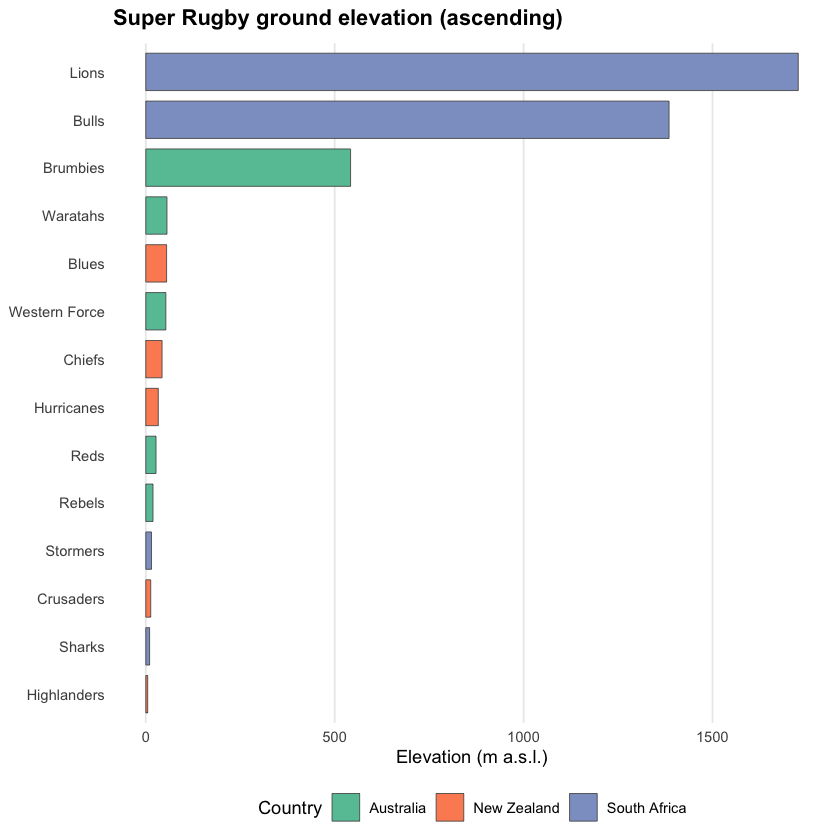

In [5]:
super_bar <- super_elev |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(super_bar, aes(x = club, y = ground_elevation_m, fill = country)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set2", name = "Country") +
  labs(
    title = "Super Rugby ground elevation (ascending)",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

**Bulls** and **Lions** again sit on the **Highveld** and pull the vertical scale upward, masking smaller differences among New Zealand and Australian venues (often coastal or low-lying basins). The chart below drops those two franchises so the **remaining twelve** grounds are easier to compare.

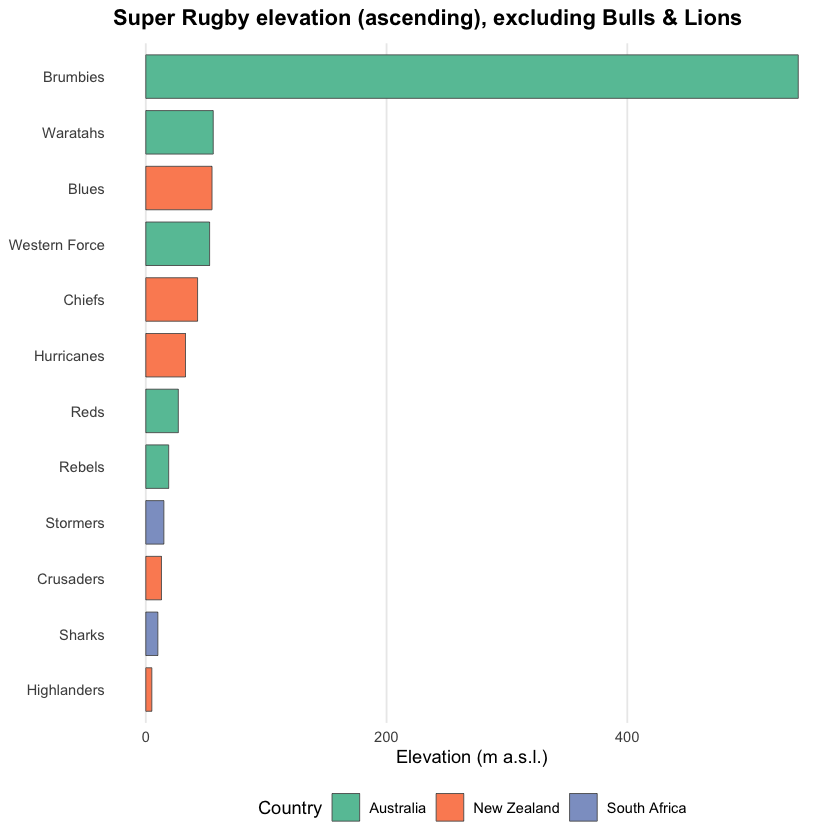

In [6]:
super_bar_trim <- super_elev |>
  dplyr::filter(!club %in% c("Bulls", "Lions")) |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(super_bar_trim, aes(x = club, y = ground_elevation_m, fill = country)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set2", name = "Country") +
  labs(
    title = "Super Rugby elevation (ascending), excluding Bulls & Lions",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

## Regional maps (New Zealand, Australia, South Africa)

We **crop** each national DEM to the stadium footprint, **merge** New Zealand and Australia for one panel, and map **South Africa** separately.

In [7]:
world_sf <- rnaturalearth::ne_countries(scale = "medium", returnclass = "sf")
super_outline_sf <- world_sf[world_sf$iso_a3 %in% c("NZL", "AUS", "ZAF"), ]
super_outline <- terra::vect(super_outline_sf)

anz_df <- super_clubs |> dplyr::filter(elev_source %in% c("NZL", "AUS"))
sa_df <- super_clubs |> dplyr::filter(elev_source == "ZAF")

anz_ext <- terra::extend(
  terra::ext(terra::vect(anz_df, geom = c("lon", "lat"), crs = "EPSG:4326")),
  2
)
sa_ext <- terra::extend(
  terra::ext(terra::vect(sa_df, geom = c("lon", "lat"), crs = "EPSG:4326")),
  2
)

r_anz <- terra::merge(
  terra::crop(elev_tiles$NZL, anz_ext),
  terra::crop(elev_tiles$AUS, anz_ext)
)
names(r_anz) <- "elevation"

r_sa <- terra::crop(elev_tiles$ZAF, sa_ext)
names(r_sa) <- "elevation"

anz_pts <- terra::vect(anz_df, geom = c("lon", "lat"), crs = "EPSG:4326")
sa_pts <- terra::vect(sa_df, geom = c("lon", "lat"), crs = "EPSG:4326")

outline_anz <- terra::crop(super_outline, anz_ext)
outline_sa <- terra::crop(super_outline, sa_ext)

if (!terra::same.crs(r_anz, outline_anz)) {
  outline_anz <- terra::project(outline_anz, r_anz)
}
if (!terra::same.crs(r_sa, outline_sa)) {
  outline_sa <- terra::project(outline_sa, r_sa)
}

<SpatRaster> resampled to 500220 cells.


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the tidyterra package.
  Please report the issue at <https://github.com/dieghernan/tidyterra/issues>.”


<SpatRaster> resampled to 500286 cells.


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


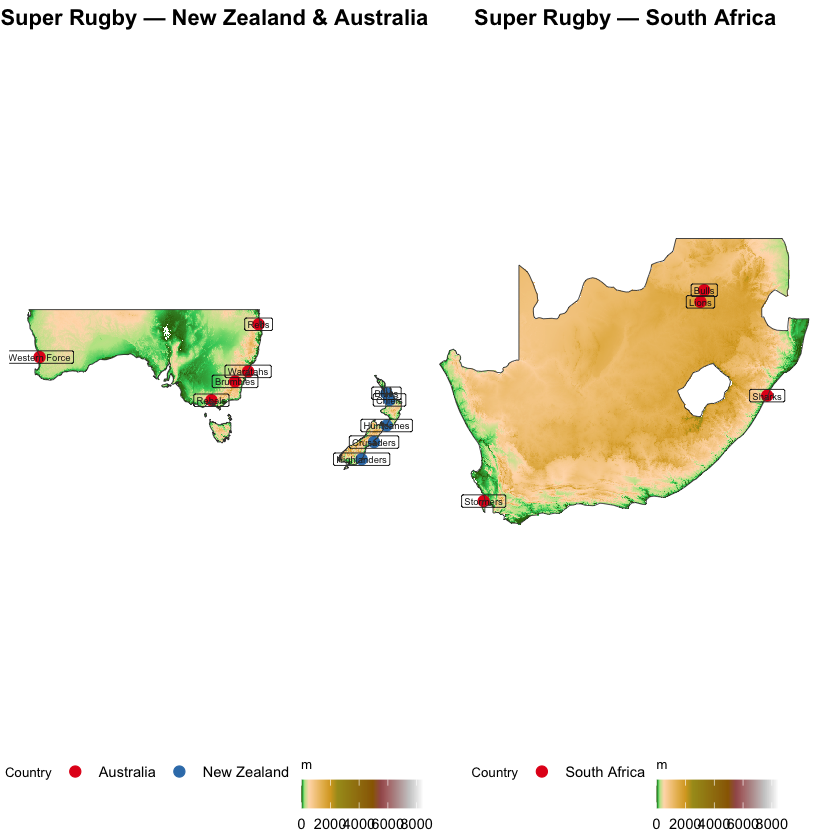

In [8]:
p_anz <- ggplot() +
  tidyterra::geom_spatraster(data = r_anz, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m",
    guide = guide_colorbar(barwidth = unit(2.6, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = anz_pts, aes(colour = country), size = 2.8, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = anz_pts,
    aes(label = club),
    size = 2,
    colour = "grey10",
    label.size = 0.12,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = outline_anz, fill = NA, colour = "grey25", linewidth = 0.25) +
  scale_colour_brewer(palette = "Set1", name = "Country") +
  labs(title = "Super Rugby — New Zealand & Australia") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, margin = margin(b = 4)),
    legend.title = element_text(size = 8),
    legend.position = "bottom"
  )

p_sa <- ggplot() +
  tidyterra::geom_spatraster(data = r_sa, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m",
    guide = guide_colorbar(barwidth = unit(2.6, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = sa_pts, aes(colour = country), size = 2.8, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = sa_pts,
    aes(label = club),
    size = 2,
    colour = "grey10",
    label.size = 0.12,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = outline_sa, fill = NA, colour = "grey25", linewidth = 0.25) +
  scale_colour_brewer(palette = "Set1", name = "Country") +
  labs(title = "Super Rugby — South Africa") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, margin = margin(b = 4)),
    legend.title = element_text(size = 8),
    legend.position = "bottom"
  )

p_anz + p_sa + patchwork::plot_layout(ncol = 2, widths = c(1, 1))

### Interactive maps

The maps below use **Leaflet** (via **`htmlwidgets`**). You can **pan**, **zoom**, and click stadium markers for **club**, **venue**, and **extracted elevation**. The elevation layer is a **downsampled** version of the same cropped DEM used in the static figures, so it loads quickly in the browser. An internet connection is required for the light **basemap** tiles.

In [9]:
flip_raster_east_west <- function(r) {
  mat <- terra::values(r, mat = TRUE)
  mat <- mat[, rev(seq_len(ncol(mat))), drop = FALSE]
  terra::values(r) <- mat
  r
}

leaflet_elev_map <- function(r, clubs_df) {
  r_small <- terra::aggregate(r, fact = 4, fun = mean)
  if (!grepl("4326", terra::crs(r_small, describe = TRUE)$code)) {
    r_small <- terra::project(r_small, "EPSG:4326")
  }
  r_small <- flip_raster_east_west(r_small)
  vals <- terra::values(r_small)
  vals <- vals[!is.na(vals)]
  elev_domain <- range(
    c(vals, clubs_df$ground_elevation_m),
    na.rm = TRUE
  )

  pal <- leaflet::colorNumeric(
    grDevices::terrain.colors(60),
    domain = elev_domain,
    na.color = "#808080"
  )

  # Plain scalars only: named bbox values break htmlwidgets JSON (fitBounds gets objects).
  lng1 <- terra::xmin(r_small)
  lng2 <- terra::xmax(r_small)
  lat1 <- terra::ymin(r_small)
  lat2 <- terra::ymax(r_small)
  bounds_ok <- all(is.finite(c(lng1, lng2, lat1, lat2))) &&
    lng1 < lng2 &&
    lat1 < lat2
  center_lng <- mean(clubs_df$lon, na.rm = TRUE)
  center_lat <- mean(clubs_df$lat, na.rm = TRUE)
  marker_fill <- unname(pal(clubs_df$ground_elevation_m))

  map <- leaflet::leaflet(
    width = "100%",
    height = 480,
    options = leaflet::leafletOptions(minZoom = 4)
  )

  map <- if (bounds_ok) {
    leaflet::fitBounds(map, lng1, lat1, lng2, lat2)
  } else {
    leaflet::setView(map, center_lng, center_lat, zoom = 4)
  }

  map |>
    leaflet::addProviderTiles(
      "CartoDB.Positron",
      group = "Basemap"
    ) |>
    leaflet::addRasterImage(
      r_small,
      colors = pal,
      opacity = 0.78,
      project = FALSE,
      group = "Elevation (SRTM)"
    ) |>
    leaflet::addLegend(
      pal = pal,
      values = vals,
      title = "Elevation (m)",
      position = "bottomright",
      opacity = 0.9
    ) |>
    leaflet::addCircleMarkers(
      lng = clubs_df$lon,
      lat = clubs_df$lat,
      radius = 8,
      stroke = TRUE,
      weight = 1.5,
      color = "#333333",
      fillColor = marker_fill,
      fillOpacity = 0.92,
      popup = paste0(
        "<strong>", clubs_df$club, "</strong><br>",
        clubs_df$stadium, "<br>",
        "<em>", clubs_df$country, "</em><br>",
        round(clubs_df$ground_elevation_m, 1), " m a.s.l."
      ),
      group = "Stadiums"
    ) |>
    leaflet::addLayersControl(
      baseGroups = "Basemap",
      overlayGroups = c("Elevation (SRTM)", "Stadiums"),
      options = leaflet::layersControlOptions(collapsed = FALSE)
    )
}

find_book_root <- function() {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  for (steps in 0:6) {
    root <- if (steps == 0) {
      wd
    } else {
      normalizePath(
        file.path(wd, paste(rep("..", steps), collapse = "/")),
        winslash = "/",
        mustWork = FALSE
      )
    }
    if (file.exists(file.path(root, "_config.yml"))) {
      return(root)
    }
  }
  stop("Could not find Jupyter Book root (_config.yml).")
}

# Full HTML documents inside .output.text_html are invalid and browsers skip the maps.
# Save self-contained widgets under book _static/ and embed with iframes.
include_leaflet_map <- function(map, title, file_stem) {
  maps_dir <- file.path(find_book_root(), "_static", "uk-terrain-rugby", "maps")
  dir.create(maps_dir, recursive = TRUE, showWarnings = FALSE)
  out_path <- file.path(maps_dir, paste0(file_stem, ".html"))
  suppressWarnings(htmlwidgets::saveWidget(map, out_path, selfcontained = TRUE))
  iframe_src <- paste0("../../_static/uk-terrain-rugby/maps/", file_stem, ".html")
  iframe_html <- sprintf(
    paste0(
      "<h4 style=\"text-align:center;font-weight:bold;margin:0.6em 0 0.2em 0;\">%s</h4>",
      "<iframe src=\"%s\" title=\"%s\" width=\"100%%\" height=\"500\" ",
      "style=\"border:none;\"></iframe>"
    ),
    htmltools::htmlEscape(title),
    iframe_src,
    htmltools::htmlEscape(title)
  )
  IRdisplay::display_html(iframe_html)
  invisible(NULL)
}

anz_elev <- super_elev |> dplyr::filter(elev_source %in% c("NZL", "AUS"))
sa_elev <- super_elev |> dplyr::filter(elev_source == "ZAF")

In [10]:
include_leaflet_map(
  leaflet_elev_map(r_anz, anz_elev),
  "Super Rugby — New Zealand & Australia (interactive)",
  "super_rugby_anz"
)
include_leaflet_map(
  leaflet_elev_map(r_sa, sa_elev),
  "Super Rugby — South Africa (interactive)",
  "super_rugby_sa"
)

Super Rugby — New Zealand & Australia (interactive)

Super Rugby — South Africa (interactive)

Across **New Zealand and Australia**, most franchises sit on **low coastal or basin** terrain in the DEM (e.g. **Blues**, **Waratahs**, **Reds**), while **South Africa** again mixes **sea-level** venues with **Highveld** outliers—useful context when comparing the full competition to **Super Rugby Pacific** today, which no longer includes the South African sides.